In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re, nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

nltk.download('stopwords', quiet=True)
stops   = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

In [2]:
qp   = pd.read_csv('query_product.csv',        encoding='iso-8859-1')
desc = pd.read_csv('product_descriptions.csv', encoding='iso-8859-1')
df = qp.merge(desc, on='product_uid', how='left')
print('shape:', df.shape)
print('missing descriptions:', df['product_description'].isna().sum())

shape: (74067, 6)
missing descriptions: 0


In [3]:
print('Query-product pairs :', len(df))
print('Unique queries      :', df['search_term'].nunique())
print('Unique products     :', df['product_uid'].nunique())
print('Avg pairs per query :', round(len(df) / df['search_term'].nunique(), 2))
print('\nRelevance summary:\n', df['relevance'].describe().round(3))
print('\nRows with relevance exactly 1/2/3:', df['relevance'].isin([1, 2, 3]).sum())

Query-product pairs : 74067
Unique queries      : 11795
Unique products     : 54667
Avg pairs per query : 6.28

Relevance summary:
 count    74067.000
mean         2.382
std          0.534
min          1.000
25%          2.000
50%          2.330
75%          3.000
max          3.000
Name: relevance, dtype: float64

Rows with relevance exactly 1/2/3: 32960


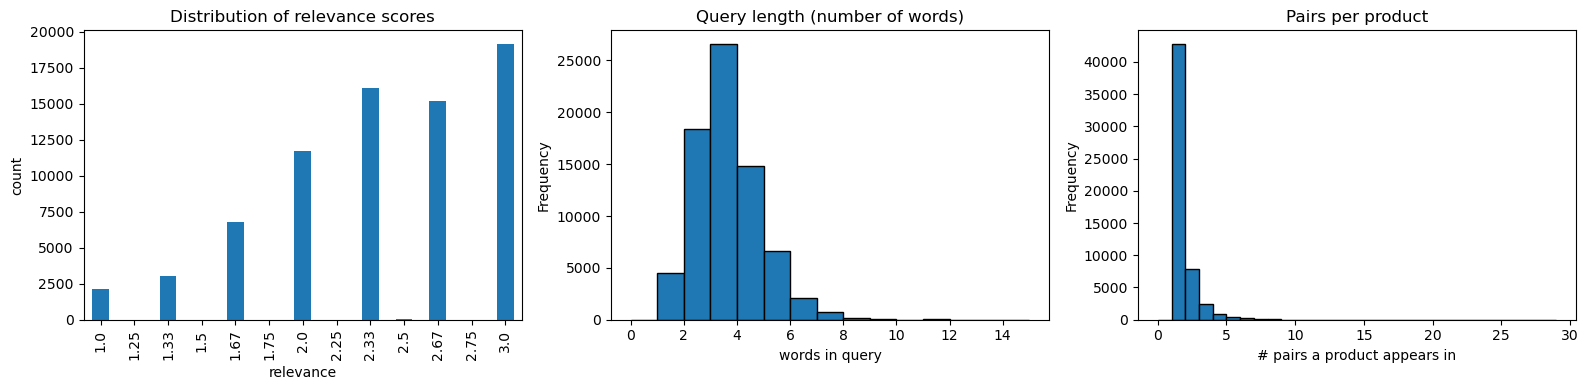

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df['relevance'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribution of relevance scores')
axes[0].set_xlabel('relevance'); axes[0].set_ylabel('count')

df['search_term'].str.split().str.len().plot(
    kind='hist', bins=range(0, 16), ax=axes[1], edgecolor='black')
axes[1].set_title('Query length (number of words)')
axes[1].set_xlabel('words in query')

df.groupby('product_uid').size().plot(
    kind='hist', bins=range(0, 30), ax=axes[2], edgecolor='black')
axes[2].set_title('Pairs per product')
axes[2].set_xlabel('# pairs a product appears in')
plt.tight_layout(); plt.show()

In [5]:
print('Duplicate (search_term, product_uid) pairs:',
      df.duplicated(subset=['search_term', 'product_uid']).sum())
print('Pairs per query  : mean %.2f, max %d' %
      (df.groupby('search_term').size().mean(), df.groupby('search_term').size().max()))
print('Pairs per product: mean %.2f, max %d' %
      (df.groupby('product_uid').size().mean(), df.groupby('product_uid').size().max()))
rng = np.random.default_rng(0)
idx = rng.permutation(len(df))
train, test = df.iloc[idx[:50000]], df.iloc[idx[50000:]]
print('Test queries also seen in train : %.1f%%' %
      (100 * test['search_term'].isin(set(train['search_term'])).mean()))
print('Test products also seen in train: %.1f%%' %
      (100 * test['product_uid'].isin(set(train['product_uid'])).mean()))
print('Distinct relevance values:', df['relevance'].nunique())
print('Share of integer relevance: %.1f%%' % (100 * df['relevance'].isin([1,2,3]).mean()))

Duplicate (search_term, product_uid) pairs: 0
Pairs per query  : mean 6.28, max 16
Pairs per product: mean 1.35, max 21
Test queries also seen in train : 96.8%
Test products also seen in train: 34.4%
Distinct relevance values: 13
Share of integer relevance: 44.5%


In [6]:
def clean(text):
    text = re.sub(r'[^a-z0-9 ]', ' ', str(text).lower())   # lowercase, drop punctuation, keep digits
    return ' '.join(stemmer.stem(t) for t in text.split() if t not in stops)

for col in ['search_term', 'product_title', 'product_description']:
    df[col + '_clean'] = df[col].map(clean)
print('done cleaning')

done cleaning


In [7]:
df.to_pickle('df_clean.pkl')
print('saved df_clean.pkl')
# to reload later instead of recomputing:
# df = pd.read_pickle('df_clean.pkl')

saved df_clean.pkl


In [8]:
q_tok = df['search_term_clean'].str.split()
t_set = df['product_title_clean'].str.split().map(set)
d_set = df['product_description_clean'].str.split().map(set)
print('token structures ready')

token structures ready


In [9]:
df['all_in_title'] = [int(len(q) > 0 and all(w in t for w in q))
                      for q, t in zip(q_tok, t_set)]
print(df['all_in_title'].value_counts())
print(df.groupby('all_in_title')['relevance'].mean().round(3))

all_in_title
0    52301
1    21766
Name: count, dtype: int64
all_in_title
0    2.267
1    2.656
Name: relevance, dtype: float64


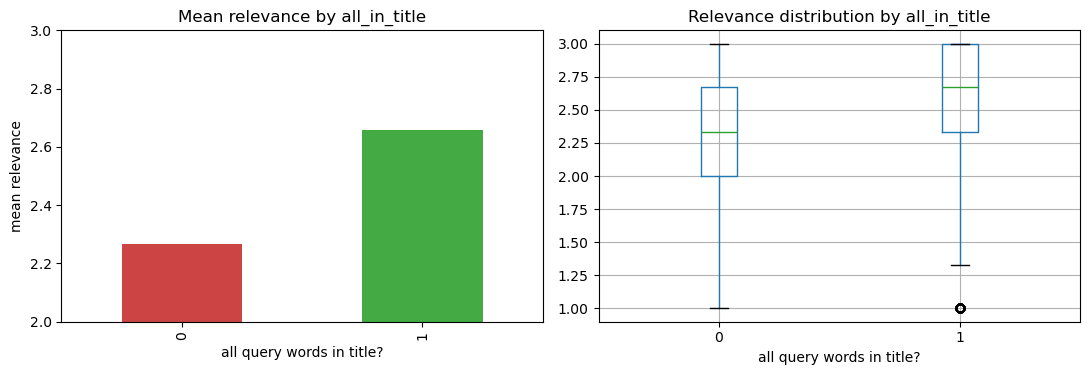

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df.groupby('all_in_title')['relevance'].mean().plot(
    kind='bar', ax=axes[0], color=['#c44', '#4a4'])
axes[0].set_title('Mean relevance by all_in_title')
axes[0].set_xlabel('all query words in title?'); axes[0].set_ylabel('mean relevance')
axes[0].set_ylim(2, 3)
df.boxplot(column='relevance', by='all_in_title', ax=axes[1])
axes[1].set_title('Relevance distribution by all_in_title')
axes[1].set_xlabel('all query words in title?')
plt.suptitle(''); plt.tight_layout(); plt.show()

In [11]:
df['n_in_title'] = [sum(w in t for w in q) for q, t in zip(q_tok, t_set)]
print(df['n_in_title'].value_counts().sort_index())
print(df.groupby('n_in_title')['relevance'].mean().round(3))

n_in_title
0      7033
1     17744
2     29144
3     13852
4      4335
5      1317
6       408
7       151
8        59
9         9
10        9
11        2
12        3
13        1
Name: count, dtype: int64
n_in_title
0     2.076
1     2.331
2     2.378
3     2.528
4     2.560
5     2.549
6     2.590
7     2.567
8     2.571
9     2.703
10    2.592
11    2.500
12    3.000
13    2.330
Name: relevance, dtype: float64


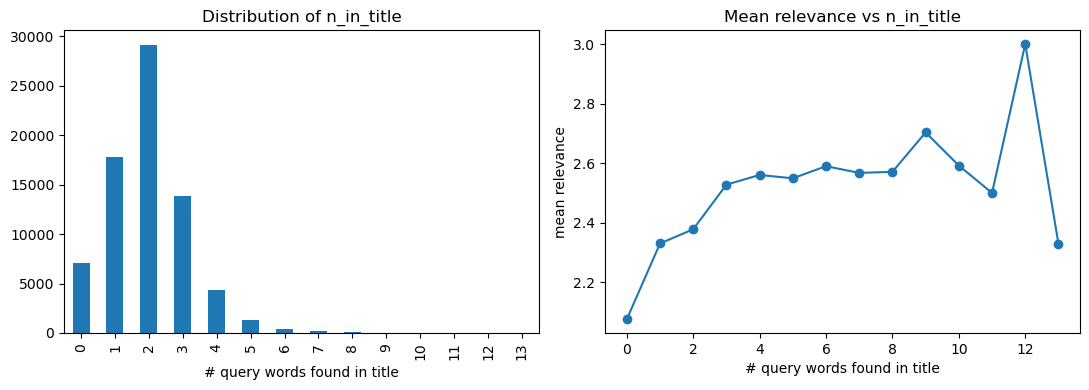

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df['n_in_title'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribution of n_in_title')
axes[0].set_xlabel('# query words found in title')
df.groupby('n_in_title')['relevance'].mean().plot(marker='o', ax=axes[1])
axes[1].set_title('Mean relevance vs n_in_title')
axes[1].set_xlabel('# query words found in title'); axes[1].set_ylabel('mean relevance')
plt.tight_layout(); plt.show()

In [13]:
df['ratio_in_title'] = [(n / len(q) if len(q) else 0)
                        for q, n in zip(q_tok, df['n_in_title'])]
print(df['ratio_in_title'].describe().round(3))
df['ratio_bin'] = pd.cut(df['ratio_in_title'], bins=[-0.01, 0, 0.25, 0.5, 0.75, 1.0])
print(df.groupby('ratio_bin', observed=True)['relevance'].mean().round(3))
print('Simple corr with relevance:', df['ratio_in_title'].corr(df['relevance']).round(3))
print(df[['all_in_title','n_in_title','ratio_in_title']].corr().round(2))

count    74067.000
mean         0.636
std          0.310
min          0.000
25%          0.500
50%          0.667
75%          1.000
max          1.000
Name: ratio_in_title, dtype: float64
ratio_bin
(-0.01, 0.0]    2.076
(0.0, 0.25]     2.102
(0.25, 0.5]     2.285
(0.5, 0.75]     2.313
(0.75, 1.0]     2.640
Name: relevance, dtype: float64
Simple corr with relevance: 0.348
                all_in_title  n_in_title  ratio_in_title
all_in_title            1.00        0.32            0.76
n_in_title              0.32        1.00            0.68
ratio_in_title          0.76        0.68            1.00


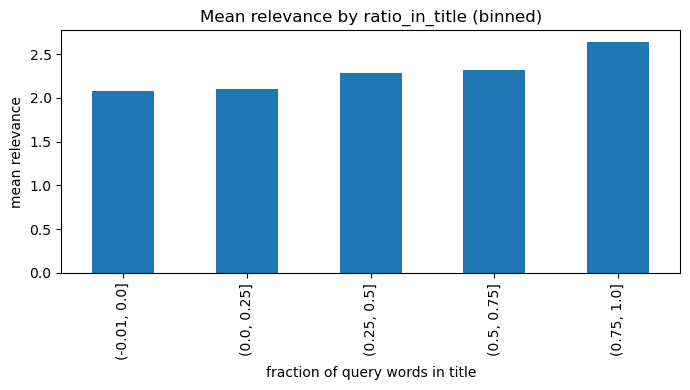

In [14]:
df.groupby('ratio_bin', observed=True)['relevance'].mean().plot(
    kind='bar', figsize=(7, 4))
plt.title('Mean relevance by ratio_in_title (binned)')
plt.xlabel('fraction of query words in title'); plt.ylabel('mean relevance')
plt.tight_layout(); plt.show()

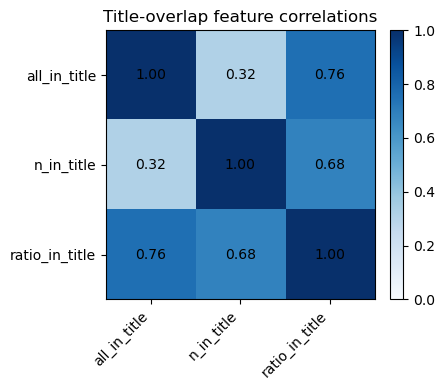

In [15]:
overlap = ['all_in_title', 'n_in_title', 'ratio_in_title']
corr = df[overlap].corr()
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(corr, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(overlap, rotation=45, ha='right')
ax.set_yticks(range(3)); ax.set_yticklabels(overlap)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
ax.set_title('Title-overlap feature correlations')
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

In [16]:
df['n_in_desc'] = [sum(w in d for w in q) for q, d in zip(q_tok, d_set)]
print(df['n_in_desc'].value_counts().sort_index())
print(df.groupby('n_in_desc')['relevance'].mean().round(3))

n_in_desc
0      8261
1     20679
2     27365
3     12561
4      3723
5      1041
6       280
7       106
8        39
9         3
10        5
12        2
13        2
Name: count, dtype: int64
n_in_desc
0     2.138
1     2.328
2     2.408
3     2.513
4     2.529
5     2.515
6     2.533
7     2.579
8     2.642
9     2.557
10    2.598
12    2.500
13    3.000
Name: relevance, dtype: float64


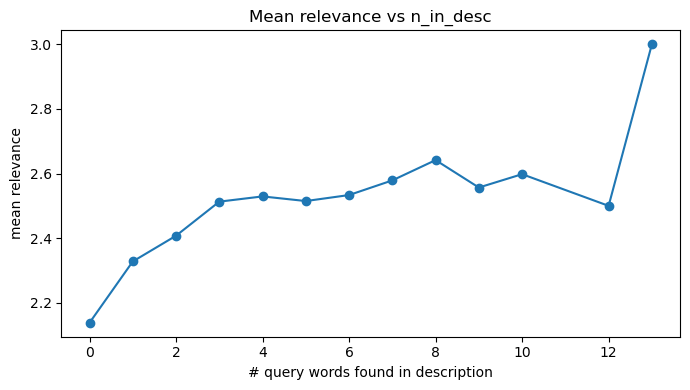

In [17]:
df.groupby('n_in_desc')['relevance'].mean().plot(marker='o', figsize=(7, 4))
plt.title('Mean relevance vs n_in_desc')
plt.xlabel('# query words found in description'); plt.ylabel('mean relevance')
plt.tight_layout(); plt.show()

In [18]:
df.to_pickle('df_features.pkl')
print('saved df_features.pkl | columns:', list(df.columns))

saved df_features.pkl | columns: ['id', 'product_uid', 'product_title', 'search_term', 'relevance', 'product_description', 'search_term_clean', 'product_title_clean', 'product_description_clean', 'all_in_title', 'n_in_title', 'ratio_in_title', 'ratio_bin', 'n_in_desc']


In [19]:
# Feature 5: query_len  — number of words in the cleaned query
df['query_len'] = df['search_term_clean'].str.split().str.len()

print(df['query_len'].describe().round(3))
print()
print(df.groupby('query_len')['relevance'].agg(['mean', 'count']).round(3))

count    74067.000
mean         3.102
std          1.232
min          0.000
25%          2.000
50%          3.000
75%          4.000
max         15.000
Name: query_len, dtype: float64

            mean  count
query_len              
0          1.551     20
1          2.270   4485
2          2.497  19398
3          2.370  26991
4          2.307  14682
5          2.335   5851
6          2.358   1623
7          2.398    595
8          2.399    292
9          2.461     86
10         2.469     17
11         2.446      9
12         2.222     12
13         2.750      4
15         2.165      2


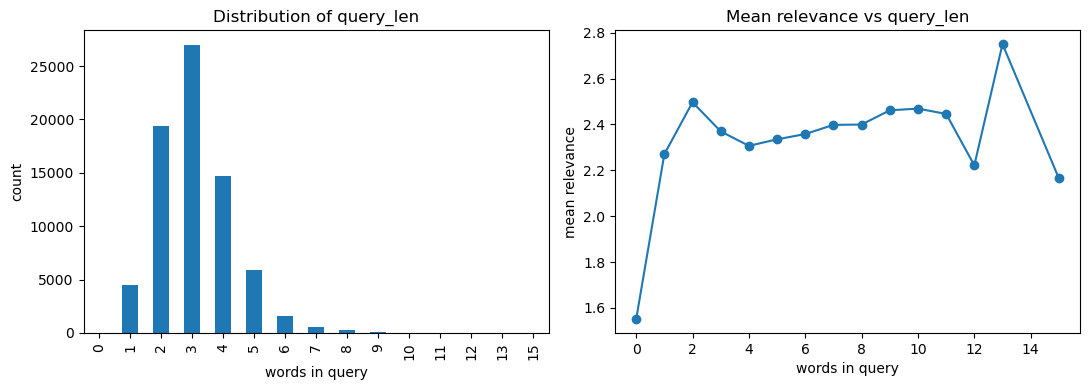

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df['query_len'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribution of query_len')
axes[0].set_xlabel('words in query'); axes[0].set_ylabel('count')

df.groupby('query_len')['relevance'].mean().plot(marker='o', ax=axes[1])
axes[1].set_title('Mean relevance vs query_len')
axes[1].set_xlabel('words in query'); axes[1].set_ylabel('mean relevance')
plt.tight_layout(); plt.show()